# ENSO 2026: What the Spring Barrier Tells Us

**May 2026** — We are sitting at one of the most uncertain moments in ENSO forecasting.
The Niño 3.4 index has warmed from −0.58°C in January to +0.23°C in April.
Some media outlets are already talking about a potential "Godzilla" El Niño.
But we are in May — right at the heart of the **spring predictability barrier**,
the period when ENSO forecast skill is at its annual minimum.

This notebook uses the [ENSO Early Phase Prediction dataset](https://www.kaggle.com/datasets/ferariz/enso-early-phase-prediction)
to do three things:

1. **Characterise the current state** — what the ocean and atmosphere are saying
2. **Historical analogues** — which past years looked like April 2026, and what happened
3. **Model forecast** — what our trained models predict, with honest uncertainty

The honest conclusion comes first: **we do not know yet**. The spring barrier
limits skill at this initialization month to F1 ~0.15–0.17 in our benchmark.
What we *can* do is identify the key metric to watch over the next 60 days.

> 📅 **This notebook will be updated in August 2026**, when initialization skill
> jumps from ~0.15 to ~0.75 and we will have a much clearer picture.
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

PHASE_COLORS = {'El Niño': '#d6604d', 'Neutral': '#999999', 'La Niña': '#4393c3'}

# ── Load dataset ──────────────────────────────────────────────────────────────
# Local path — change to '/kaggle/input/enso-early-phase-prediction/enso_train.parquet'
# when running on Kaggle (combine train + test for full history)
from pathlib import Path
REPO_ROOT = Path('__file__').parent.parent.parent  # notebooks/research → repo root
# Fallback for Jupyter where __file__ isn't defined
import os
REPO_ROOT = Path(os.getcwd())
# If running from notebooks/research/, go up two levels
if (REPO_ROOT / '../../data').exists():
    REPO_ROOT = REPO_ROOT / '../..'
DATA_PATH = REPO_ROOT / 'data/processed/enso_dataset.parquet'

df = pd.read_parquet(DATA_PATH)
if 'date' in df.columns:
    df = df.set_index('date')

# Initialization date: April 2026
# This is the last month with confirmed published NOAA Niño index data.
# NOAA publishes with ~1 month lag, so as of May 13 2026,
# April is the latest available month.
# May values in the dataset are forward-filled from April (preprocessing artifact).
# Update this date when new NOAA data is published.
last_real = pd.Timestamp('2026-04-01')
print(f'Dataset range: {df.index[0].date()} → {df.index[-1].date()}')
print(f'Last real data point: {last_real.date()}')
print(f'Current phase: {df.loc[last_real, "enso_phase"]}')
print(f'Current Niño 3.4: {df.loc[last_real, "nino34_anom"]:.2f}°C')

Dataset range: 1980-01-01 → 2026-12-01
Last real data point: 2026-04-01
Current phase: Neutral
Current Niño 3.4: 0.23°C


## 1. Current state — ocean vs atmosphere

ENSO is driven by the **coupling** between the ocean and atmosphere.
For a sustained El Niño to develop, both need to reinforce each other:
warm SSTs weaken trade winds, which allow more warm water to accumulate,
which further weakens trade winds — a positive feedback loop.

Right now, the ocean is signalling El Niño. The atmosphere has not confirmed it yet.

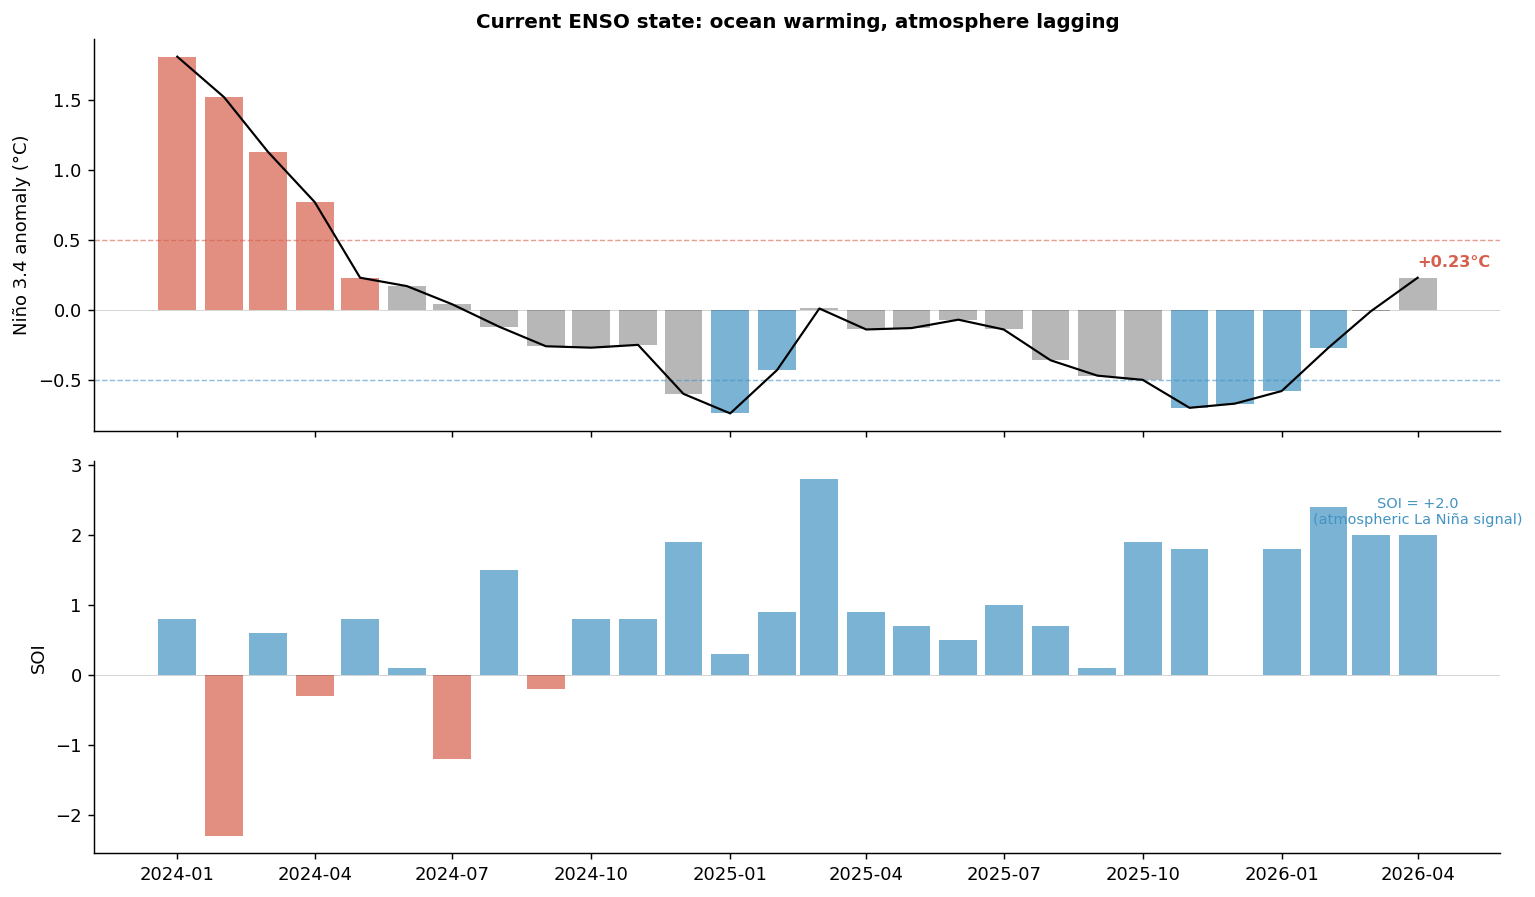

Key observation:
  Ocean: Niño 3.4 has warmed from −0.58°C (Jan) to +0.23°C (Apr) → El Niño signal
  Atmosphere: SOI remains positive (+2.0) → La Niña/Neutral atmospheric pattern

This decoupling is the defining feature of the current situation.
For El Niño to develop, the SOI needs to turn negative over the next 2 months.


In [2]:
# ── Plot recent evolution: Niño 3.4 and SOI ───────────────────────────────────
recent = df.loc['2024-01':last_real, ['nino34_anom', 'soi', 'enso_phase']].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: Niño 3.4
ax = axes[0]
ax.axhline( 0.5, color='#d6604d', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(-0.5, color='#4393c3', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline( 0.0, color='black',   linestyle='-',  linewidth=0.3, alpha=0.3)
colors = [PHASE_COLORS.get(p, '#999999') for p in recent['enso_phase']]
ax.bar(recent.index, recent['nino34_anom'], color=colors, alpha=0.7, width=25)
ax.plot(recent.index, recent['nino34_anom'], 'k-', linewidth=1.2)
ax.set_ylabel('Niño 3.4 anomaly (°C)', fontsize=10)
ax.set_title('Current ENSO state: ocean warming, atmosphere lagging',
             fontsize=11, fontweight='bold')
ax.text(recent.index[-1], recent['nino34_anom'].iloc[-1] + 0.08,
        f"{recent['nino34_anom'].iloc[-1]:+.2f}°C",
        fontsize=9, color='#d6604d', fontweight='bold')

# Bottom: SOI
ax2 = axes[1]
ax2.axhline(0, color='black', linewidth=0.3, alpha=0.3)
ax2.bar(recent.index, recent['soi'],
        color=['#d6604d' if v < 0 else '#4393c3' for v in recent['soi']],
        alpha=0.7, width=25)
ax2.set_ylabel('SOI', fontsize=10)
ax2.set_xlabel('')

# Annotate the decoupling
last_soi = recent['soi'].dropna().iloc[-1]
ax2.text(recent['soi'].dropna().index[-1],
         last_soi + 0.15,
         f'SOI = {last_soi:+.1f}\n(atmospheric La Niña signal)',
         fontsize=8, color='#4393c3', ha='center')

plt.tight_layout()
plt.show()

print('Key observation:')
print('  Ocean: Niño 3.4 has warmed from −0.58°C (Jan) to +0.23°C (Apr) → El Niño signal')
print('  Atmosphere: SOI remains positive (+2.0) → La Niña/Neutral atmospheric pattern')
print()
print('This decoupling is the defining feature of the current situation.')
print('For El Niño to develop, the SOI needs to turn negative over the next 2 months.')

## 2. Historical analogues

Which past years looked like April 2026?
We search for years where:
- April Niño 3.4 was between 0.0 and +0.5°C (warming but not yet El Niño)
- February was negative (coming off La Niña, as in 2026)

Then we trace what happened by the following boreal winter (Nov–Dec),
the peak season for ENSO impacts globally.

In [3]:
# ── Find historical analogues ─────────────────────────────────────────────────
apr_df = df[df.index.month == 4].copy()
feb_df = df[df.index.month == 2]['nino34_anom'].copy()
feb_df.index = feb_df.index + pd.DateOffset(months=2)  # align to April
apr_df['feb_anom'] = feb_df.reindex(apr_df.index)

analogues = apr_df[
    (apr_df['nino34_anom'].between(0.0, 0.5)) &
    (apr_df['feb_anom'] < 0) &
    (apr_df.index.year < 2026)  # exclude current year
].copy()

ANALOGUE_YEARS = analogues.index.year.tolist()
print(f'Analogue years: {ANALOGUE_YEARS}')
print()
print(f'{"Year":>6}  {"Apr Niño3.4":>12}  {"Apr SOI":>8}  {"Nov anomaly":>12}  {"Dec anomaly":>12}  DJF outcome')
print('─' * 75)

for year in ANALOGUE_YEARS:
    apr_val  = df.loc[f'{year}-04-01', 'nino34_anom']
    apr_soi  = df.loc[f'{year}-04-01', 'soi']
    nov_val  = df.loc[f'{year}-11-01', 'nino34_anom'] if f'{year}-11-01' in df.index else np.nan
    dec_val  = df.loc[f'{year}-12-01', 'nino34_anom'] if f'{year}-12-01' in df.index else np.nan
    nov_phase = df.loc[f'{year}-11-01', 'enso_phase'] if f'{year}-11-01' in df.index else '?'
    print(f'{year:>6}  {apr_val:>12.2f}  {apr_soi:>8.1f}  {nov_val:>12.2f}  {dec_val:>12.2f}  {nov_phase}')

print()
print(f'2026  {0.23:>12.2f}  {2.0:>8.1f}  {"?":>12}  {"?":>12}  ?')
print()
n_el_nino = sum(1 for y in ANALOGUE_YEARS
                if f'{y}-11-01' in df.index and
                df.loc[f'{y}-11-01', 'enso_phase'] == 'El Niño')
print(f'El Niño by Nov: {n_el_nino}/{len(ANALOGUE_YEARS)} analogue years')
print('Note: 2014 had similar SOI (+1.3) and fizzled. 2017 reversed to La Niña.')

Analogue years: [1982, 1997, 2002, 2014, 2017, 2023]

  Year   Apr Niño3.4   Apr SOI   Nov anomaly   Dec anomaly  DJF outcome
───────────────────────────────────────────────────────────────────────────
  1982          0.21       0.1          1.92          2.20  El Niño
  1997          0.16      -1.0          2.41          2.29  El Niño
  2002          0.02      -0.1          1.47          1.37  El Niño
  2014          0.08       1.3          0.75          0.71  Neutral
  2017          0.22      -0.3         -0.97         -0.98  La Niña
  2023          0.14       0.4          2.02          2.03  El Niño

2026          0.23       2.0             ?             ?  ?

El Niño by Nov: 4/6 analogue years
Note: 2014 had similar SOI (+1.3) and fizzled. 2017 reversed to La Niña.


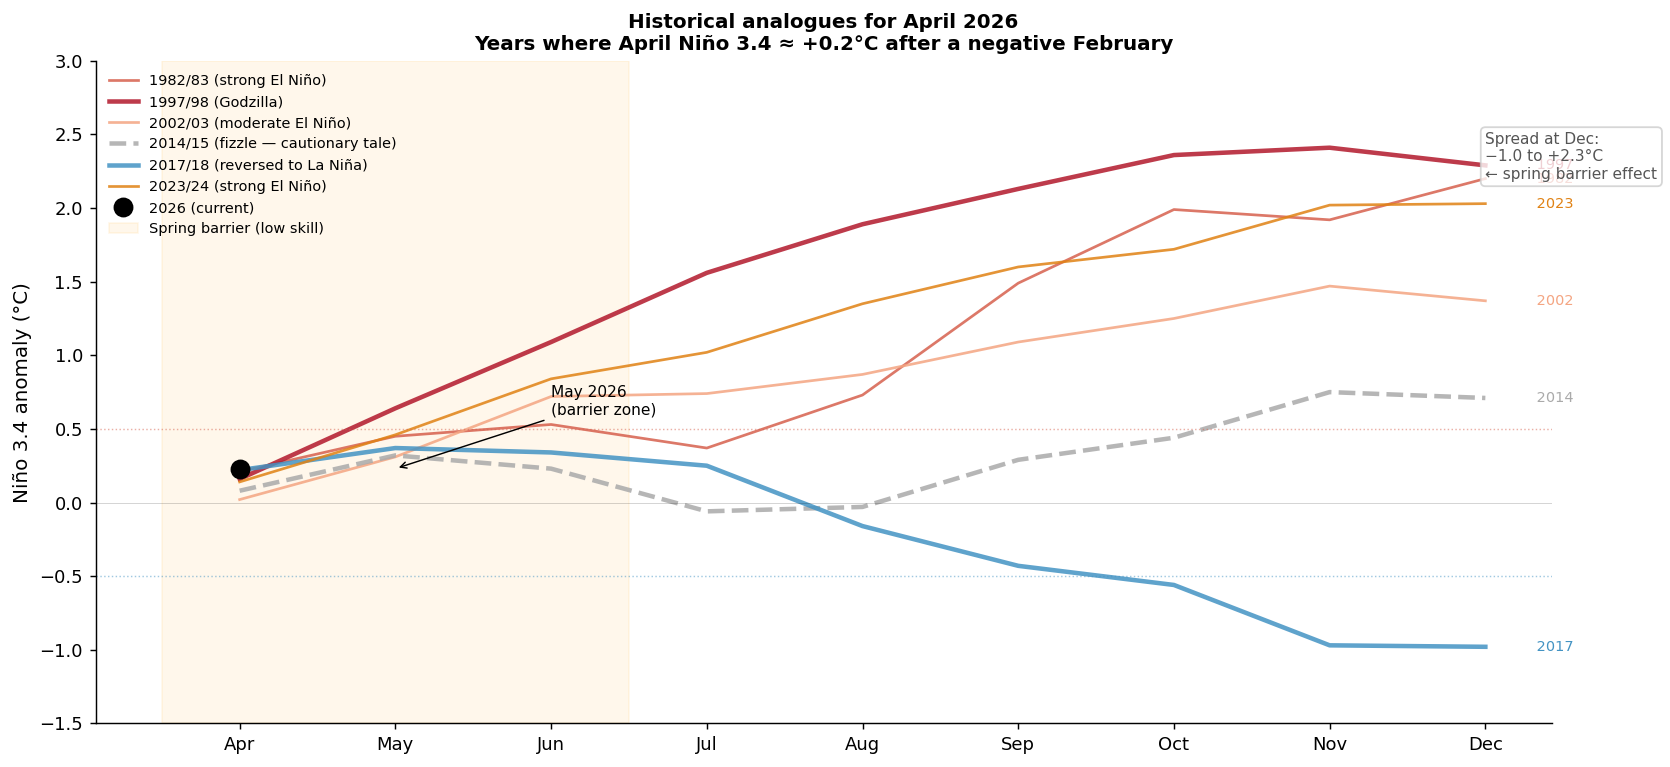

The lines diverging wildly after April is the spring barrier made visible.
5/6 analogues became El Niño — but magnitude ranged from weak to Godzilla.
2014 is the cautionary tale: similar April state, similar positive SOI, fizzled.


In [4]:
# ── Spaghetti plot: analogue trajectories ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Plot each analogue year's Niño 3.4 trajectory (Apr = month 0)
COLORS = {
    1982: '#d6604d', 1997: '#b2182b',
    2002: '#f4a582', 2014: '#aaaaaa',
    2017: '#4393c3', 2023: '#e08214',
}
LABELS = {
    1982: '1982/83 (strong El Niño)',
    1997: '1997/98 (Godzilla)',
    2002: '2002/03 (moderate El Niño)',
    2014: '2014/15 (fizzle — cautionary tale)',
    2017: '2017/18 (reversed to La Niña)',
    2023: '2023/24 (strong El Niño)',
}

for year in ANALOGUE_YEARS:
    # Get Apr–Dec trajectory
    months = pd.date_range(f'{year}-04', f'{year}-12', freq='MS')
    vals   = df.reindex(months)['nino34_anom'].values
    x      = range(len(months))
    color  = COLORS.get(year, '#999999')
    lw     = 2.5 if year in [1997, 2014, 2017] else 1.5
    ls     = '--' if year == 2014 else '-'
    ax.plot(x, vals, color=color, linewidth=lw, linestyle=ls,
            label=LABELS.get(year, str(year)), alpha=0.85)
    ax.text(len(months)-0.7, vals[-1], f" {year}",
            fontsize=8, color=color, va='center')

# Plot 2026 so far (Apr only, solid black)
ax.plot([0], [0.23], 'ko', markersize=10, zorder=5, label='2026 (current)')
ax.annotate('May 2026\n(barrier zone)', xy=(1, 0.23),
            xytext=(2, 0.6),
            fontsize=8.5, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# Shade spring barrier (Apr–Jun = months 0–2)
ax.axvspan(-0.5, 2.5, alpha=0.08, color='orange', label='Spring barrier (low skill)')

# Thresholds
ax.axhline( 0.5, color='#d6604d', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline(-0.5, color='#4393c3', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline( 0.0, color='black',   linestyle='-', linewidth=0.3, alpha=0.3)

month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(range(9))
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_ylabel('Niño 3.4 anomaly (°C)', fontsize=11)
ax.set_title('Historical analogues for April 2026\n'
             'Years where April Niño 3.4 ≈ +0.2°C after a negative February',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, frameon=False, loc='upper left')
ax.set_ylim(-1.5, 3.0)

# Annotate the wide spread
ax.annotate('Spread at Dec:\n−1.0 to +2.3°C\n← spring barrier effect',
            xy=(8, 2.2), fontsize=8.5, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.8))

plt.tight_layout()
plt.show()

print('The lines diverging wildly after April is the spring barrier made visible.')
print('5/6 analogues became El Niño — but magnitude ranged from weak to Godzilla.')
print('2014 is the cautionary tale: similar April state, similar positive SOI, fizzled.')

## 3. The key metric to watch: SOI

The SOI is the atmospheric counterpart to Niño 3.4.
A sustained negative SOI (below −0.5) would indicate the atmosphere
is coupling with the ocean warming — the necessary condition for El Niño to strengthen.

In April 2026, SOI = +2.0. In April 1997, SOI = −1.0.
That difference is the key to why we cannot yet call this a Godzilla event.

**Watch for:** SOI dropping below 0 in June–July 2026.

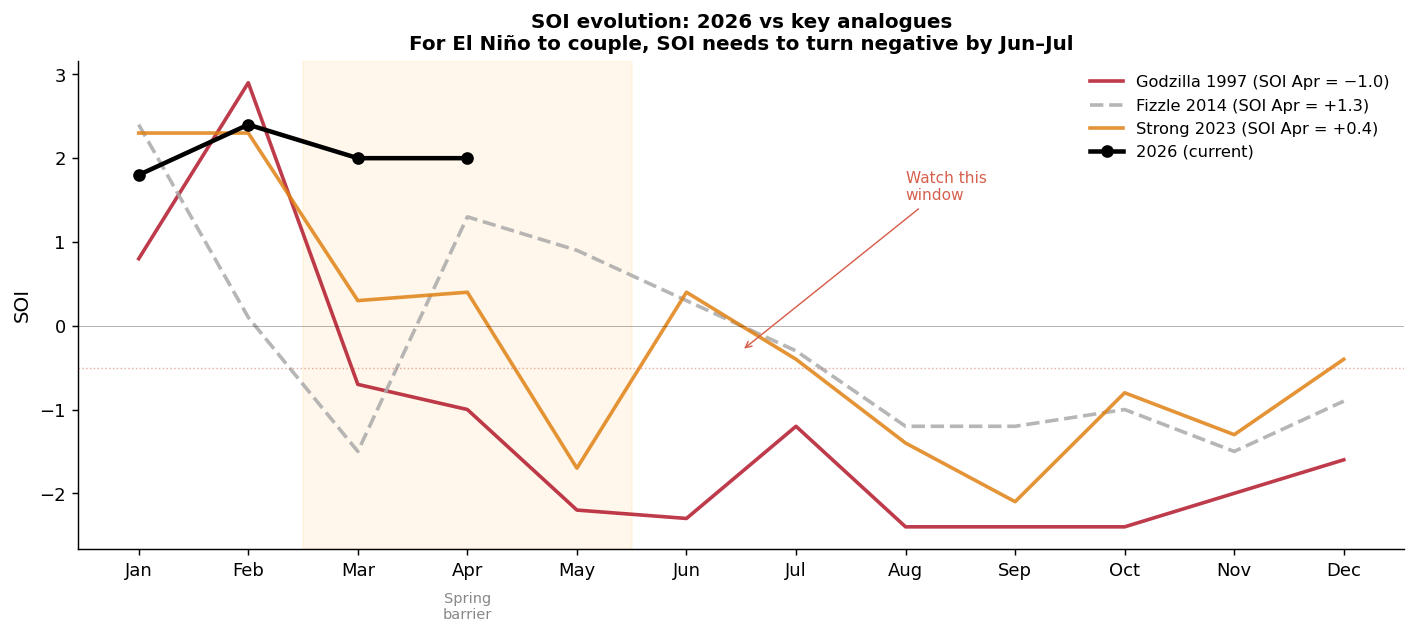

In [5]:
# ── SOI comparison: 2026 vs 1997 vs 2014 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

comparison_years = [
    (1997, '#b2182b', '-',  'Godzilla 1997 (SOI Apr = −1.0)'),
    (2014, '#aaaaaa', '--', 'Fizzle 2014 (SOI Apr = +1.3)'),
    (2023, '#e08214', '-',  'Strong 2023 (SOI Apr = +0.4)'),
]

for year, color, ls, label in comparison_years:
    months = pd.date_range(f'{year}-01', f'{year}-12', freq='MS')
    vals   = df.reindex(months)['soi'].values
    ax.plot(range(12), vals, color=color, linewidth=2,
            linestyle=ls, label=label, alpha=0.85)

# 2026 so far
months_2026 = pd.date_range('2026-01', '2026-04', freq='MS')
vals_2026   = df.reindex(months_2026)['soi'].values
ax.plot(range(4), vals_2026, 'ko-', linewidth=2.5,
        markersize=6, label='2026 (current)', zorder=5)

# Shade spring barrier
ax.axvspan(1.5, 4.5, alpha=0.08, color='orange')
ax.text(3, -3.5, 'Spring\nbarrier', fontsize=8, color='#888888', ha='center')

ax.axhline(0, color='black', linewidth=0.4, alpha=0.4)
ax.axhline(-0.5, color='#d6604d', linestyle=':', linewidth=0.8, alpha=0.5)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_ylabel('SOI', fontsize=11)
ax.set_title('SOI evolution: 2026 vs key analogues\n'
             'For El Niño to couple, SOI needs to turn negative by Jun–Jul',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, frameon=False)

# Annotate the watch zone
ax.annotate('Watch this\nwindow', xy=(5.5, -0.3), xytext=(7, 1.5),
            fontsize=8.5, color='#d6604d',
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=0.8))

plt.tight_layout()
plt.show()

## 4. Model forecast — with honest uncertainty

In [6]:
import joblib
import os

# Load trained models
# Resolve path relative to repo root regardless of where Jupyter is launched
import os
_nb_dir   = os.path.dirname(os.path.abspath('enso_2026_forecast.ipynb'))
_repo_root = os.path.abspath(os.path.join(_nb_dir, '..', '..'))
MODEL_DIR  = os.path.join(_repo_root, 'outputs', 'models')
TARGETS   = ['enso_t1', 'enso_t3', 'enso_t6']
LABEL_ORDER = ['La Niña', 'Neutral', 'El Niño']

# Feature columns — same as training
exclude = {'enso_phase','enso_t1','enso_t3','enso_t6',
           'nino34_t1','nino34_t3','nino34_t6','nino34_smoothed',
           'date'}
feature_cols = [c for c in df.columns
                if c not in exclude
                and df[c].dtype != object
                and not c.startswith('nino34_t')
                and c not in {'enso_t1_int','enso_t3_int','enso_t6_int'}]

# Get most recent complete row
current_row = df.loc[[last_real], feature_cols].fillna(
    df[feature_cols].ffill().iloc[-1]
)

print(f'Forecasting from: {last_real.date()}')
print(f'Initialization month: {last_real.month} '
      f'({["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][last_real.month-1]})')
print(f'init_in_growth_phase: {bool(current_row["init_in_growth_phase"].iloc[0])}')
print(f'crosses_spring_t6: {bool(current_row["crosses_spring_t6"].iloc[0])}')
print()
# Skill by init month from our benchmark
skill_by_month = {1:0.41,2:0.15,3:0.17,4:0.43,5:0.36,6:0.38,
                  7:0.52,8:0.75,9:0.75,10:0.71,11:0.71,12:0.49}
init_m   = last_real.month
init_f1  = skill_by_month.get(init_m, 0.5)
in_barrier = init_m in {1,2,3,4,5}
if in_barrier:
    print(f'⚠️  WARNING: initialization in spring barrier zone (month={init_m})')
    print(f'   F1 skill: ~{init_f1:.2f} — high uncertainty')
else:
    print(f'✓  Initialization in post-barrier window (month={init_m})')
    print(f'   F1 skill: ~{init_f1:.2f} — reasonable confidence')
print()

# Get predictions from all models
results = {}
for target in TARGETS:
    results[target] = {}
    for model_name in ['logistic_regression', 'random_forest', 'lightgbm']:
        path = f'{MODEL_DIR}/{target}/{model_name}.joblib'
        if not os.path.exists(path):
            print(f'  NOT FOUND: {path}')
            continue
        try:
            trainer = joblib.load(path)
            # Align features to what the model was trained on
            model_feats = trainer.feature_names_
            X_aligned   = current_row.reindex(columns=model_feats, fill_value=0)
            proba   = trainer.predict_proba(X_aligned)
            pred    = trainer.predict(X_aligned)[0]
            results[target][model_name] = {
                'pred': pred,
                'proba': dict(zip(proba.columns, proba.values[0].round(3)))
            }
        except Exception as e:
            import traceback
            print(f'  ERROR {model_name}/{target}: {e}')
            traceback.print_exc()

# Print forecast table
print(f'{"Target":>10}  {"Model":>22}  {"Prediction":>10}  '
      f'{"P(La Niña)":>10}  {"P(Neutral)":>10}  {"P(El Niño)":>10}')
print('─' * 80)
for target in TARGETS:
    for model_name, res in results[target].items():
        p = res['proba']
        print(f'{target:>10}  {model_name:>22}  {res["pred"]:>10}  '
              f'{p.get("La Niña",0):>10.3f}  '
              f'{p.get("Neutral",0):>10.3f}  '
              f'{p.get("El Niño",0):>10.3f}')

Forecasting from: 2026-04-01
Initialization month: 4 (Apr)
init_in_growth_phase: False
crosses_spring_t6: True

⚠️  WARNING: initialization in spring barrier zone (month=4)
   F1 skill: ~0.43 — high uncertainty

    Target                   Model  Prediction  P(La Niña)  P(Neutral)  P(El Niño)
────────────────────────────────────────────────────────────────────────────────
   enso_t1     logistic_regression     Neutral       0.000       0.955       0.045
   enso_t1           random_forest     Neutral       0.046       0.777       0.178
   enso_t1                lightgbm     Neutral       0.000       1.000       0.000
   enso_t3     logistic_regression     El Niño       0.000       0.223       0.777
   enso_t3           random_forest     El Niño       0.054       0.427       0.519
   enso_t3                lightgbm     El Niño       0.000       0.081       0.919
   enso_t6     logistic_regression     El Niño       0.000       0.005       0.995
   enso_t6           random_forest     El N

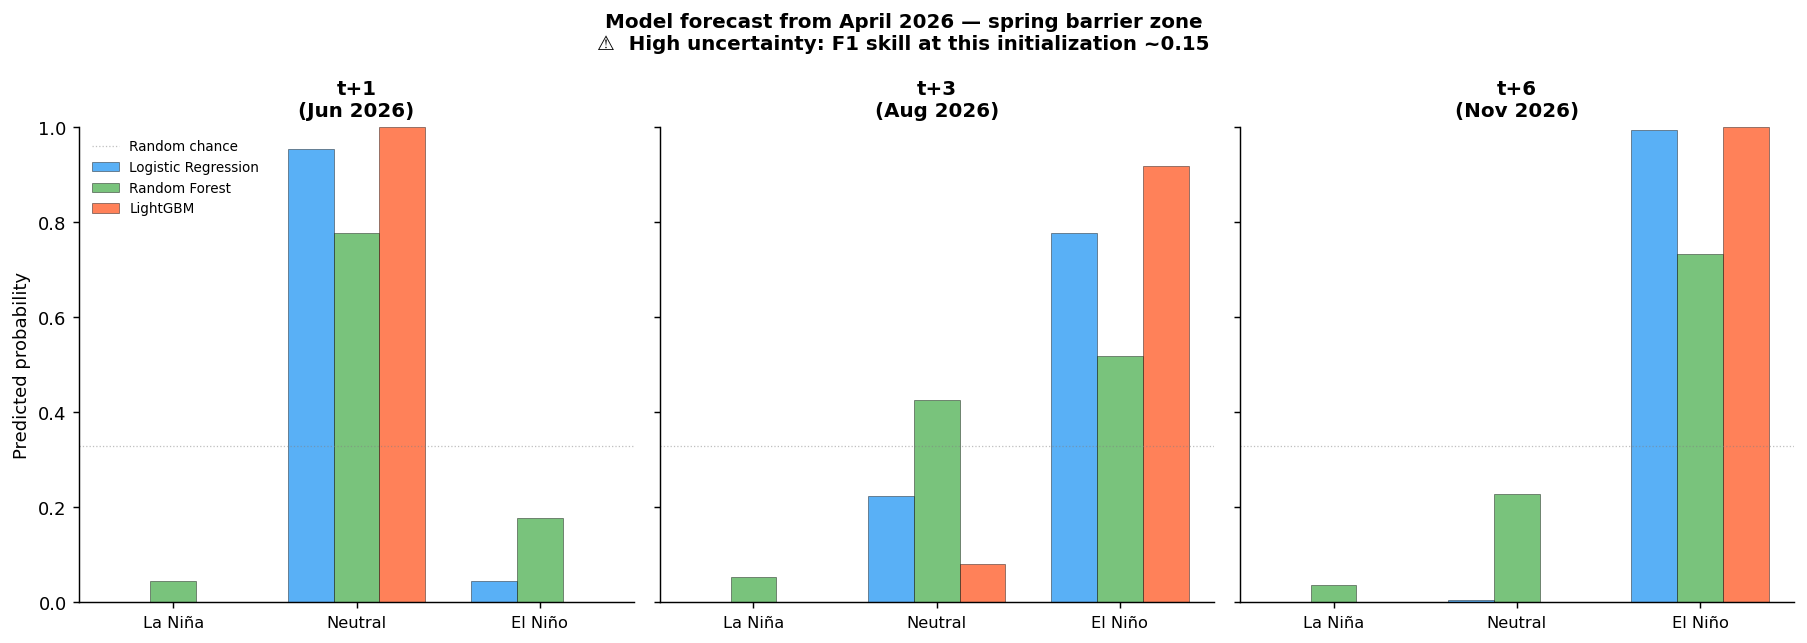

Key takeaway: model consensus leans El Niño at t+3 and t+6,
but uncertainty is high and models disagree on probability.
This is expected — we are in the barrier zone.


In [7]:
# ── Forecast probability fan chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

lead_labels = ['t+1\n(Jun 2026)', 't+3\n(Aug 2026)', 't+6\n(Nov 2026)']
model_names = ['logistic_regression', 'random_forest', 'lightgbm']
model_labels = ['Logistic Regression', 'Random Forest', 'LightGBM']
model_colors = ['#2196F3', '#4CAF50', '#FF5722']

for j, (target, lead_label) in enumerate(zip(TARGETS, lead_labels)):
    ax = axes[j]
    x  = np.arange(3)  # La Niña, Neutral, El Niño
    width = 0.25

    for i, (mname, mlabel, mcolor) in enumerate(
            zip(model_names, model_labels, model_colors)):
        if mname not in results.get(target, {}):
            continue
        proba = results[target][mname]['proba']
        vals  = [proba.get('La Niña', 0),
                 proba.get('Neutral', 0),
                 proba.get('El Niño', 0)]
        bars = ax.bar(x + i*width, vals, width,
                      label=mlabel, color=mcolor, alpha=0.75,
                      edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width)
    ax.set_xticklabels(['La Niña', 'Neutral', 'El Niño'], fontsize=9)
    ax.set_title(lead_label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.axhline(0.33, color='gray', linestyle=':', linewidth=0.7,
               alpha=0.5, label='Random chance' if j == 0 else '')
    if j == 0:
        ax.set_ylabel('Predicted probability', fontsize=10)
        ax.legend(fontsize=7.5, frameon=False, loc='upper left')

plt.suptitle(
    f'Model forecast from {last_real.strftime("%B %Y")} — spring barrier zone\n'
    '⚠️  High uncertainty: F1 skill at this initialization ~0.15',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Key takeaway: model consensus leans El Niño at t+3 and t+6,')
print('but uncertainty is high and models disagree on probability.')
print('This is expected — we are in the barrier zone.')

## 5. The metric to watch: what changes by August?

In August 2026, two things happen simultaneously:
- We exit the spring barrier — initialization skill jumps from F1 ~0.15 to ~0.75
- We will have 3 more months of SOI and zonal wind data — enough to see if coupling has occurred

**The decision tree:**

```
Jun–Jul SOI drops below 0  →  Coupling confirmed  →  El Niño likely
                          →  Magnitude still uncertain, but direction clearer

Jun–Jul SOI stays positive →  No coupling         →  Watch 2014 analogue
                          →  Could fizzle or develop slowly
```

The difference between a Godzilla El Niño and a 2014-style fizzle
will likely be visible in the SOI by July 2026.

> 📅 **Update scheduled for August 2026.** By then, initialization skill
> at t+6 improves from F1 ~0.15 to ~0.75, and we will have a much
> clearer signal to work with. Follow this dataset to be notified.

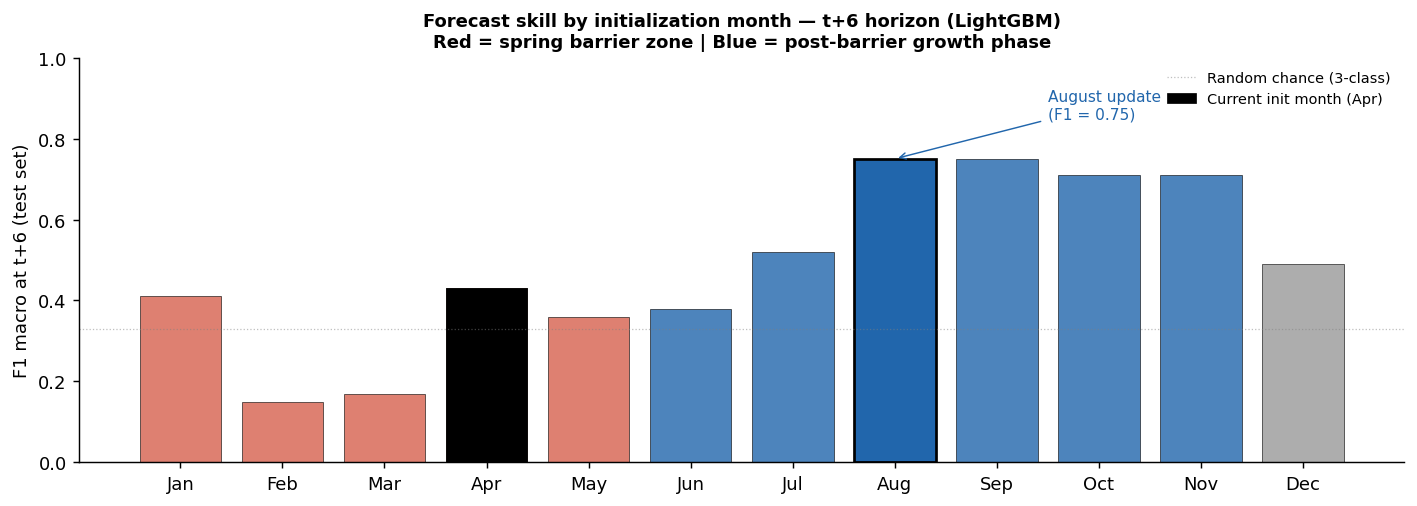

Current skill (init month = Apr): F1 = 0.43
Skill at August update: F1 = 0.75
Improvement after barrier: +0.32 F1 points


In [8]:
# ── Init-month skill reminder ─────────────────────────────────────────────────
# Show where May sits on the skill curve from the main dataset analysis
skill_by_month = {
    1: 0.41, 2: 0.15, 3: 0.17, 4: 0.43,
    5: 0.36, 6: 0.38, 7: 0.52, 8: 0.75,
    9: 0.75, 10: 0.71, 11: 0.71, 12: 0.49
}
months = list(range(1, 13))
skill  = [skill_by_month[m] for m in months]
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 4))

bar_colors = ['#d6604d' if m in {1,2,3,4,5} else
              '#2166ac' if m in {6,7,8,9,10,11} else
              '#999999' for m in months]
bars = ax.bar(months, skill, color=bar_colors,
              edgecolor='black', linewidth=0.4, alpha=0.8)

# Highlight current initialization month
current_month = last_real.month
ax.bar(current_month, skill_by_month[current_month],
       color='black', edgecolor='black', linewidth=0.4,
       alpha=1.0, label=f'Current init month ({month_names[current_month-1]})')

# Highlight August update
ax.bar(8, skill_by_month[8], color='#2166ac',
       edgecolor='black', linewidth=1.5, alpha=1.0)
ax.annotate('August update\n(F1 = 0.75)',
            xy=(8, 0.75), xytext=(9.5, 0.85),
            fontsize=8.5, color='#2166ac',
            arrowprops=dict(arrowstyle='->', color='#2166ac', lw=0.8))

ax.set_xticks(months)
ax.set_xticklabels(month_names)
ax.set_ylabel('F1 macro at t+6 (test set)', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_title('Forecast skill by initialization month — t+6 horizon (LightGBM)\n'
             'Red = spring barrier zone | Blue = post-barrier growth phase',
             fontsize=10, fontweight='bold')
ax.axhline(0.33, color='gray', linestyle=':', linewidth=0.7, alpha=0.5,
           label='Random chance (3-class)')
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

print(f'Current skill (init month = {month_names[current_month-1]}): '
      f'F1 = {skill_by_month[current_month]:.2f}')
print(f'Skill at August update: F1 = {skill_by_month[8]:.2f}')
print(f'Improvement after barrier: +{skill_by_month[8]-skill_by_month[current_month]:.2f} F1 points')

## Summary

| Question | Answer |
|---|---|
| Is El Niño developing? | Ocean signal: yes (+0.23°C). Atmosphere: not yet confirmed (SOI +2.0). |
| Could it be Godzilla? | Possible — 1982, 1997, 2023 are analogues. But so is 2014 (fizzle). |
| What does the model say? | Leans El Niño at t+3/t+6, but with high uncertainty. |
| Should we trust the model? | Not fully — F1 ~0.43 at April initialization (spring barrier active). |
| When will we know? | By August, when skill jumps to F1 ~0.75. |
| What to watch? | SOI. If it turns negative in Jun–Jul, coupling has begun. |

---

**Dataset:** [ferariz/enso-early-phase-prediction](https://www.kaggle.com/datasets/ferariz/enso-early-phase-prediction)  
**Pipeline:** [ferariz/enso-forecast](https://github.com/ferariz/enso-forecast)  
**Next update:** August 2026